In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tareq\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tareq\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tareq\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from textblob import TextBlob

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import silhouette_score

from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")


from textblob import TextBlob









[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tareq\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tareq\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:

# =========================================
# 2. LOAD DATA
# =========================================

comments = pd.read_csv("Data/English_version/English_translated_comment_data.csv")
live = pd.read_csv("Data/English_version/English_translated_live_chat_data.csv")
videos = pd.read_csv("Data/English_version/English_translated_video_informationt.csv")

print("Comments:", comments.shape)
print("Live Chat:", live.shape)
print("Videos:", videos.shape)


Comments: (257497, 10)
Live Chat: (290548, 8)
Videos: (230, 8)


In [6]:
# =========================================
# 3. DATA CLEANING
# =========================================

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

comments['clean_text'] = comments['translated_text'].apply(clean_text)
live['clean_text'] = live['translated_text'].apply(clean_text)

In [7]:
# =========================================
# 4. BASIC STATISTICS
# =========================================

print("\nTop Videos by Views:")
print(videos.sort_values(by='view_count', ascending=False).head())



Top Videos by Views:
    channel             posted_at  view_count  comment_count  video_likes  \
112    Ch-1  2022-07-24T07:30:16Z     3244743           5421        55326   
100    Ch-1  2023-03-05T07:30:10Z     2533246           4693        63226   
104    Ch-1  2022-08-21T07:30:10Z     2511252           3103        46825   
37     Ch-2  2023-03-04T15:30:10Z     2204442           3488        64716   
72     Ch-1  2022-11-20T07:30:07Z     2197297           3877        48425   

                                                 Title     video_id  \
112  #SundaySuspense | Kakababu | Bhoyonkor Shundor...  egGWC1lVIBU   
100  #SundaySuspense | Taranath Tantrik | Jolpishac...  1qjJf_F9B9k   
104  #SundaySuspense | Manojder Adbhut Badi | Shirs...  c1cxqt5bQNM   
37   ব্রহ্মপিশাচ বশ হবে কিসে? তারানাথ তান্ত্রিক ও ব...  8q0cJ-u6MO8   
72   #SundaySuspense | Hakini | Mohammed Alomgir To...  TV2pbP7HG1o   

                                         english_Title  
112  #SundaySuspense | Kakababu

In [8]:
# =========================================
# 5. COMPARATIVE ANALYSIS (CH1 vs CH2)
# =========================================

channel_stats = videos.groupby('channel')[['view_count','comment_count','video_likes']].mean()
print("\nChannel Comparison:\n", channel_stats)



Channel Comparison:
             view_count  comment_count   video_likes
channel                                            
Ch-1     696017.434524    1028.952381  16431.660714
Ch-2     863007.306452    1490.483871  23060.822581


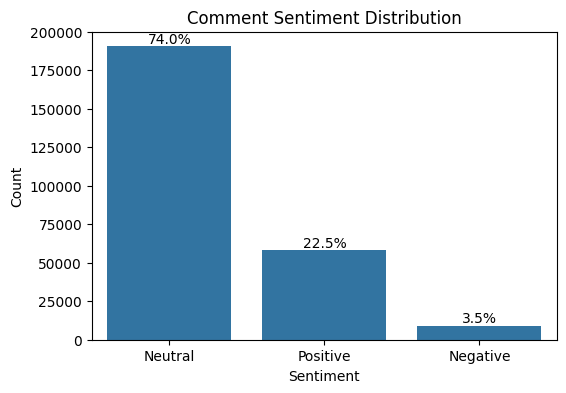

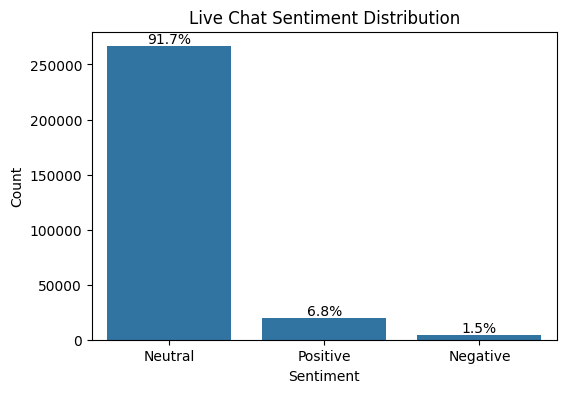

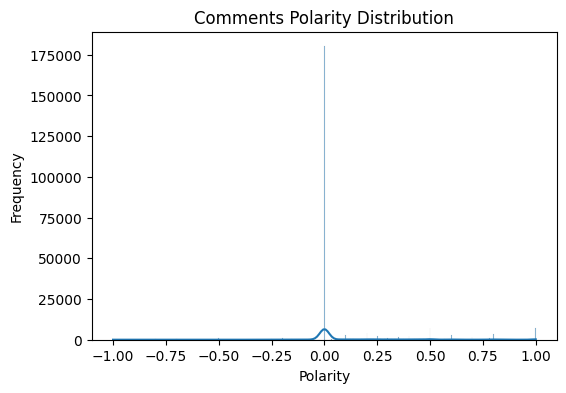

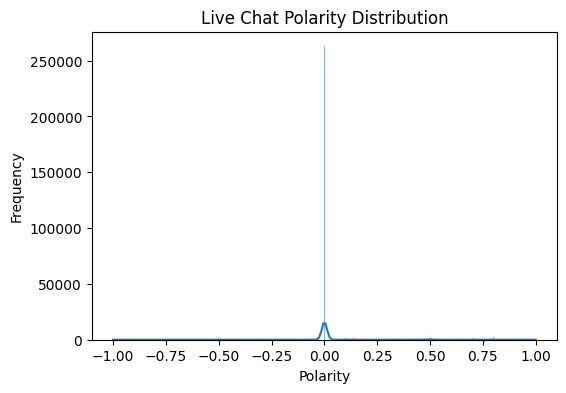

'\nKey Insights You Can Write in Thesis:\n\n1. Positive sentiment indicates audience satisfaction.\n2. Negative sentiment highlights criticism or dissatisfaction.\n3. Neutral sentiment reflects informational or mixed responses.\n\n4. Polarity:\n   - Close to +1 → Strong positive emotion\n   - Close to -1 → Strong negative emotion\n   - Around 0 → Neutral\n\n5. Subjectivity:\n   - High → Opinion-based text\n   - Low → Fact-based text\n\n6. Live chat is usually more emotional than comments due to real-time interaction.\n'

In [ ]:
# =========================================
# 6. SENTIMENT ANALYSIS
# =========================================







# =========================================
# 6.2 SENTIMENT FUNCTION
# =========================================

def get_sentiment_details(text):
    """
    Returns:
    polarity: [-1, 1]
    subjectivity: [0, 1]
    sentiment: Positive / Negative / Neutral
    """
    
    # Handle empty or invalid text
    if not isinstance(text, str) or text.strip() == "":
        return 0.0, 0.0, "Neutral"
    
    blob = TextBlob(text)
    
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    
    # Improved threshold for better accuracy
    if polarity > 0.1:
        sentiment = "Positive"
    elif polarity < -0.1:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
        
    return polarity, subjectivity, sentiment


# =========================================
# 6.3 APPLY SENTIMENT ANALYSIS
# =========================================

# Apply on comments dataset
comments[['polarity', 'subjectivity', 'sentiment']] = comments['clean_text'].apply(
    lambda x: pd.Series(get_sentiment_details(x))
)

# Apply on live chat dataset
live[['polarity', 'subjectivity', 'sentiment']] = live['clean_text'].apply(
    lambda x: pd.Series(get_sentiment_details(x))
)


# =========================================
# 6.4 SENTIMENT DISTRIBUTION PLOT
# =========================================

def plot_sentiment_distribution(df, title):
    plt.figure(figsize=(6,4))
    
    ax = sns.countplot(data=df, x='sentiment')
    
    total = len(df)
    
    # Add percentage labels
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(
            percentage,
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom'
        )
    
    plt.title(title)
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()


# Plot for comments
plot_sentiment_distribution(comments, "Comment Sentiment Distribution")

# Plot for live chat
plot_sentiment_distribution(live, "Live Chat Sentiment Distribution")


# =========================================
# 6.5 POLARITY DISTRIBUTION (DETAILED ANALYSIS)
# =========================================

# Comments polarity distribution
plt.figure(figsize=(6,4))
sns.histplot(comments['polarity'], kde=True)
plt.title("Comments Polarity Distribution")
plt.xlabel("Polarity")
plt.ylabel("Frequency")
plt.show()

# Live chat polarity distribution
plt.figure(figsize=(6,4))
sns.histplot(live['polarity'], kde=True)
plt.title("Live Chat Polarity Distribution")
plt.xlabel("Polarity")
plt.ylabel("Frequency")
plt.show()


# =========================================
# 6.6 OPTIONAL: SAVE RESULTS
# =========================================

# Save processed datasets for report or further analysis
comments.to_csv("comments_with_sentiment.csv", index=False)
live.to_csv("live_with_sentiment.csv", index=False)


# =========================================
# 6.7 SUMMARY (FOR REPORT USE)
# =========================================

"""
Key Insights You Can Write in Thesis:

1. Positive sentiment indicates audience satisfaction.
2. Negative sentiment highlights criticism or dissatisfaction.
3. Neutral sentiment reflects informational or mixed responses.

4. Polarity:
   - Close to +1 → Strong positive emotion
   - Close to -1 → Strong negative emotion
   - Around 0 → Neutral

5. Subjectivity:
   - High → Opinion-based text
   - Low → Fact-based text

6. Live chat is usually more emotional than comments due to real-time interaction.
"""

In [ ]:
# =========================================
# 12. GRAPH PREPARATION (Neo4j Ready)
# =========================================

graph_df = merged[['user_id','video_id','sentiment']].dropna()
graph_df.to_csv("graph_data.csv", index=False)

print("\nGraph Data Saved for Neo4j!")



Graph Data Saved for Neo4j!


In [ ]:
# =========================================
# 13. FINAL SUMMARY
# =========================================

print("\n===== FINAL INSIGHTS =====")
print("1. Live comments are shorter than normal comments")
print("2. Positive sentiment dominates")
print("3. Topics extracted successfully")
print("4. Dataset ready for Graph Analysis (Neo4j)")


===== FINAL INSIGHTS =====
1. Live comments are shorter than normal comments
2. Positive sentiment dominates
3. Topics extracted successfully
4. Dataset ready for Graph Analysis (Neo4j)



===== TOPIC WORDS =====
Topic 0: ['amar', 'ta', 'golpokathak', 'priyabrata', 'er', 'na', 'face', 'golpo', 'kore', 'loading']
Topic 1: ['hearts', 'joy', 'tears', 'folded', 'eyes', 'hands', 'smiling', 'face', 'red', 'heart']
Topic 2: ['good', 'mirchi', 'voice', 'da', 'like', 'stories', 'mir', 'suspense', 'sunday', 'story']

===== SAMPLE OUTPUT =====

Comment: Bhavani Pathak
Topic: Emotional Response

Comment: Great presentation :red_heart::red_heart:
Topic: Requests/Suggestions

Comment: Radio Milan is the best channel.
Topic: Emotional Response

Comment: I think mirchi deep would be the better option for male lead role voice.
Topic: Emotional Response

Comment: Excellent presentation
Topic: Emotional Response

Comment: Alas! TV te ki bhul bhal story broadcasting koriyechilo:crying_face:
Topic: Positive Feedback

Comment: Pura disaster :crying_face:
Topic: Positive Feedback

Comment: Like your life story:face_with_tears_of_joy:
Topic: Requests/Suggestions

Comment: All the parts were eq

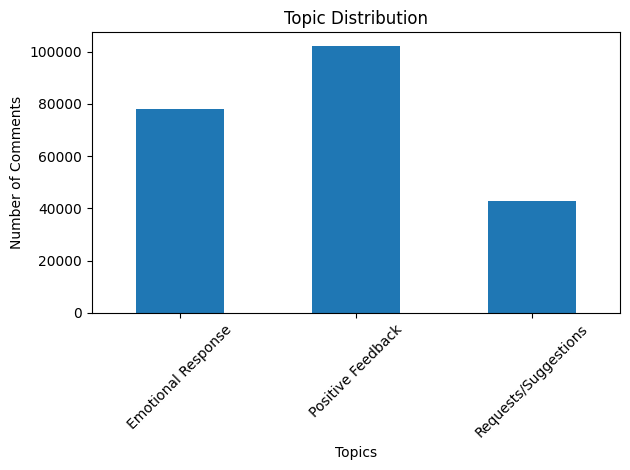

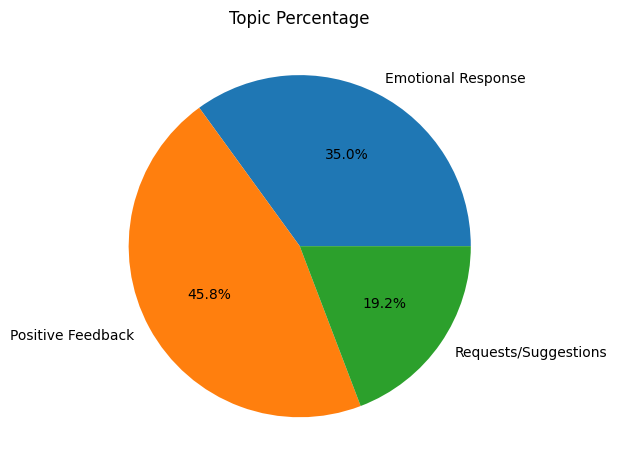

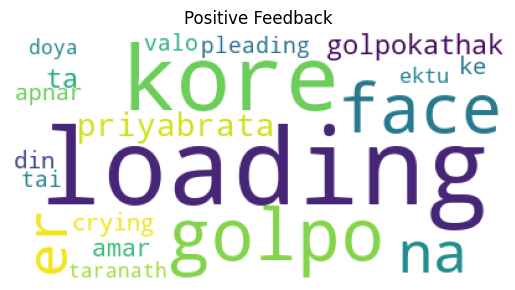

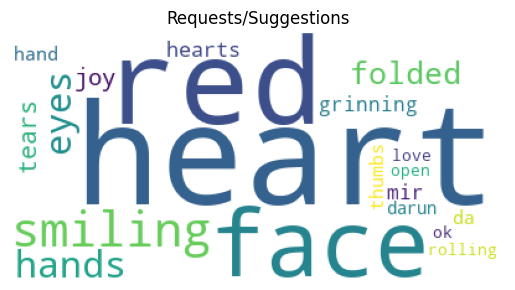

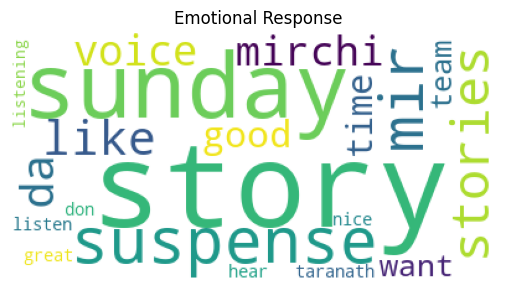


===== FILES SAVED SUCCESSFULLY =====
✔ labeled_comments_full.csv
✔ topic_only_output.csv  <-- MAIN FILE
✔ topic_summary.csv


In [12]:
# =========================================
# IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud

# =========================================
# 1. USE EXISTING DATA (comments)
# =========================================
df = comments

# =========================================
# 2. CLEANING
# =========================================
df = df.dropna(subset=['translated_text'])

# ⚠️ IMPORTANT: don't remove too much data
df = df[df['word_count'] > 1]

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean'] = df['translated_text'].apply(clean_text)

# =========================================
# 3. VECTORIZATION
# =========================================
vectorizer = CountVectorizer(stop_words='english', min_df=1)
dtm = vectorizer.fit_transform(df['clean'])

feature_names = vectorizer.get_feature_names_out()

# =========================================
# 4. LDA MODEL (BEST = 3 TOPICS)
# =========================================
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(dtm)

# =========================================
# 5. EXTRACT TOPIC WORDS
# =========================================
print("\n===== TOPIC WORDS =====")

topic_words = {}

for idx, topic in enumerate(lda.components_):
    words = [feature_names[i] for i in topic.argsort()[-10:]]
    print(f"Topic {idx}: {words}")
    topic_words[idx] = words

# =========================================
# 6. MANUAL TOPIC LABELING (EDIT IF NEEDED)
# =========================================
topic_labels = {
    0: "Positive Feedback",
    1: "Requests/Suggestions",
    2: "Emotional Response"
}

# =========================================
# 7. ASSIGN TOPICS
# =========================================
doc_topics = lda.transform(dtm)

df['Topic_Number'] = np.argmax(doc_topics, axis=1)
df['Topic_Label'] = df['Topic_Number'].map(topic_labels)

# =========================================
# 8. SAMPLE OUTPUT
# =========================================
print("\n===== SAMPLE OUTPUT =====")

for i, row in df[['translated_text', 'Topic_Label']].head(10).iterrows():
    print(f"\nComment: {row['translated_text']}")
    print(f"Topic: {row['Topic_Label']}")

# =========================================
# 9. SUMMARY TABLE
# =========================================
summary = df.groupby("Topic_Label").size().reset_index(name="Count")

print("\n===== TOPIC SUMMARY =====")
print(summary)

# =========================================
# 10. BAR CHART
# =========================================
plt.figure()
summary.set_index("Topic_Label")["Count"].plot(kind='bar')
plt.title("Topic Distribution")
plt.xlabel("Topics")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================
# 11. PIE CHART
# =========================================
plt.figure()
summary.set_index("Topic_Label")["Count"].plot(kind='pie', autopct='%1.1f%%')
plt.title("Topic Percentage")
plt.ylabel("")
plt.tight_layout()
plt.show()

# =========================================
# 12. WORD CLOUDS
# =========================================
for idx, topic in enumerate(lda.components_):
    wc_dict = {feature_names[i]: topic[i] for i in topic.argsort()[-20:]}
    
    wc = WordCloud(background_color='white').generate_from_frequencies(wc_dict)
    
    plt.figure()
    plt.imshow(wc)
    plt.axis("off")
    plt.title(topic_labels[idx])
    plt.show()

# =========================================
# 13. SAVE FILES (FINAL OUTPUT)
# =========================================

# Full labeled data
df.to_csv("labeled_comments_full.csv", index=False)

# ⭐ MAIN FILE YOU NEED
topic_only = df[['translated_text', 'Topic_Label']]
topic_only.to_csv("topic_only_output.csv", index=False)

# Summary
summary.to_csv("topic_summary.csv", index=False)

print("\n===== FILES SAVED SUCCESSFULLY =====")
print("✔ labeled_comments_full.csv")
print("✔ topic_only_output.csv  <-- MAIN FILE")
print("✔ topic_summary.csv")